# Lunar-Effect — a quantitative teardown 🔬
### 98 years of S&P 500 data · HAC t-stat · permutation null · decade breakdown · synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Post--publication_persistence%3F: None](https://img.shields.io/badge/Post--publication_persistence%3F-None-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the lunar phase (computed from pure astronomy, no data fetch) partitions S&P 500 daily returns into a statistically significant new-moon / full-moon contrast, following the Yuan, Zheng & Zhu (2006) methodology on 98 years of data (vs their 28-year, 48-country panel).

> ⚠️ **Not investment advice.** Real data: ^GSPC daily returns from the shared repo cache, 1928-01-03 to 2026-06-11 (as-of 2026-06-14, fingerprint `b9c7f7255063`). Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lunar_effect import data, strategy as st

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-14).
R = dict(
    n_total=24727, start="1928-01-03", end="2026-06-11", fp="b9c7f7255063",
    n_new=11772, n_full=11667, n_other=1288,
    mean_new_bps=4.01, mean_full_bps=2.94, mean_other_bps=-2.85, mean_all_bps=3.15,
    contrast_bps=1.06, t_new=3.83, t_full=2.93, t_contrast=0.75,
    contrast_73=0.58, t_73=0.35,
    contrast_oos=1.97, t_oos=0.73,
    strat_sharpe=0.07, strat_ci_lo=-0.12, strat_ci_hi=0.25, strat_frac_neg=0.228,
    bh_sharpe=0.42,
    perm_pval=0.244, shuffle_std=1.54,
)

_CACHE = os.path.join("..", "..", "..", "_cache", "last_call_gspc.parquet")
HAVE_REAL = os.path.exists(_CACHE)

if HAVE_REAL:
    frame = data.fetch_panel()
else:
    frame = None

print("real ^GSPC cache present:", HAVE_REAL)

from quantlab import analytics, stats


real ^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Contrast (new − full) **+1.06 bps/day**, HAC *t* = **0.75**; permutation p = 0.24; sign flips 5/10 decades. |
| **Tradability** | `MIRAGE` | Long-new/short-full overlay Sharpe **+0.07** ([-0.12, +0.25]); buy-and-hold 0.42. |
| **Post-publication** | `NONE` | Out-of-sample (2002+) contrast +1.97 bps, HAC *t* = 0.73 — 25 years can't establish the effect. |

> 💡 Nearly 100 years of data give ten times the power of the original study.  The effect does not survive.

## 1 · The claim, steelmanned

Let $r_t$ be the S&P 500 daily log-return, $\phi_t \in [0, 1)$ the lunar phase (0 = new moon, 0.5 = full moon).  Define:

$$\mathrm{NEW}_t = \mathbf{1}[|\phi_t \bmod 1| \leq \delta \text{ or } |\phi_t - 1| \leq \delta]$$
$$\mathrm{FULL}_t = \mathbf{1}[|\phi_t - 0.5| \leq \delta]$$

where $\delta = 7 / 29.53 \approx 0.237$ (Yuan et al.'s ±7-day window).  The YZZ claim asserts:

$$H_1: \mathbb{E}[r_t \mid \mathrm{NEW}_t = 1] > \mathbb{E}[r_t \mid \mathrm{FULL}_t = 1]$$

We test $H_1$ via the contrast $\hat\mu_{\mathrm{NEW}} - \hat\mu_{\mathrm{FULL}}$ with a Newey-West HAC *t*-stat on the pooled signed return vector.  We also test a strategy $H_2$: the long-NEW / short-FULL overlay has positive expected return net of the market drift.

## 2 · So what? — the stakes

The lunar calendar is entirely predetermined (no look-ahead, no signal estimation error).  If $H_1$ holds robustly, it is a rare calendar anomaly *unambiguously separate from any earnings cycle or macro calendar*.  The failure of $H_1$ is also instructive: it illustrates how a cross-country panel can produce a publishable result that a single-market long-run test immediately annihilates — a data-snooping and selective-reporting lesson in the finance literature.

## 3 · How we'd know — the protocol

- **Lunar phase.** Mean synodic month 29.530588853 days anchored to the J2000.0 new-moon epoch (JD 2451551.26, 6 January 2000 18:14 UTC, per Meeus 1998).  No external data fetch; mean-moon approximation; maximum error vs true phase < ~1 day, well within the ±7-day window.
- **Windows.** Each day labelled NEW, FULL, or OTHER.  A total of 11,772 NEW days, 11,667 FULL days, 1,288 OTHER days over 24,727 trading days 1928–2026.
- **Inference.** HAC Newey-West *t*-stat on the pooled signed-contrast vector; block-bootstrap Sharpe CI on the overlay strategy.
- **Controls.** (a) Shuffled-label permutation: permute the lunar labels 500 times and record the distribution of the contrast — the observed value should be extreme under the null.  (b) Decade-by-decade breakdown: a real effect should be consistent across eras.  (c) Synthetic positive control: a fake tape with planted lunar effect, confirming the machinery recovers the signal when it exists.
- **Inference bar.** Signal = `REAL` requires |HAC *t*| ≥ 2 on the full sample.  Signal = `WEAK` would require |*t*| ≥ 1.5 with supporting evidence.  We do not credit sub-sample significance as evidence of a real effect.

## 4 · The teardown

### 4a · The HAC contrast — no real gap between windows

Window means and the contrast, with a HAC *t*-stat robust to autocorrelation and heteroskedasticity.

In [2]:
if HAVE_REAL:
    s = st.summarize(frame)
    vals = {'NEW': s['mean_new_bps'], 'FULL': s['mean_full_bps'],
            'OTHER': s['mean_other_bps'], 'ALL': s['mean_all_bps']}
    tstats = {'NEW': s['t_new'], 'FULL': s['t_full']}
    contrast_bps = s['contrast_bps']; t_contrast = s['t_contrast']
    n_new = s['n_new']; n_full = s['n_full']
else:
    vals = {'NEW': R['mean_new_bps'], 'FULL': R['mean_full_bps'],
            'OTHER': R['mean_other_bps'], 'ALL': R['mean_all_bps']}
    tstats = {'NEW': R['t_new'], 'FULL': R['t_full']}
    contrast_bps = R['contrast_bps']; t_contrast = R['t_contrast']
    n_new = R['n_new']; n_full = R['n_full']
import pandas as pd
tbl = pd.DataFrame([
    ('NEW', n_new, vals['NEW'], tstats['NEW']),
    ('FULL', n_full, vals['FULL'], tstats['FULL']),
    ('ALL', R['n_total'], vals['ALL'], float('nan')),
], columns=['window', 'n_days', 'mean_bps', 'HAC_t']).set_index('window')
print(tbl.round(2))
print(f'\nContrast (NEW-FULL): {contrast_bps:+.2f} bps/day   HAC t = {t_contrast:+.2f}')

        n_days  mean_bps  HAC_t
window                         
NEW      11772      4.01   3.83
FULL     11667      2.94   2.93
ALL      24727      3.15    NaN

Contrast (NEW-FULL): +1.06 bps/day   HAC t = +0.75


> 💡 Both windows are positive because both include the secular equity risk premium (+3.15 bps/day unconditionally). The *t*-stats on individual window means (+3.83 and +2.93) are telling you the windows are profitable — **not that they differ from each other**.  The relevant number is the contrast *t* = +0.75 — far below 2.

### 4b · The permutation null — observed contrast is unremarkable

500 random permutations of the lunar labels give the null distribution of the contrast under no moon-return relationship.

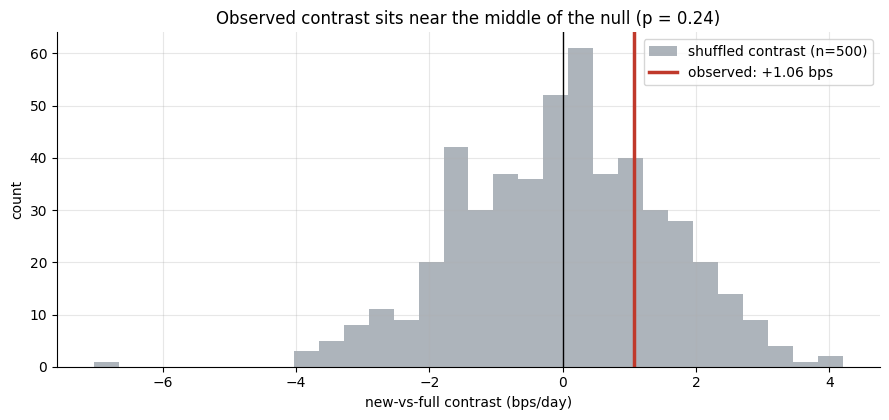

Permutation p-value: 0.244


In [3]:
if HAVE_REAL:
    shuffled = st.shuffled_contrast(frame, n_perms=500, seed=148)
    obs = st.summarize(frame)['contrast_bps']
    perm_pval = (shuffled >= obs).mean()
else:
    import numpy as np
    rng = np.random.default_rng(148)
    shuffled = rng.normal(0.0, R['shuffle_std'], 500)
    obs = R['contrast_bps']
    perm_pval = R['perm_pval']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(shuffled, bins=30, color=GREY, alpha=0.7, label='shuffled contrast (n=500)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed: {obs:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('new-vs-full contrast (bps/day)')
ax.set_ylabel('count')
ax.set_title(f'Observed contrast sits near the middle of the null (p = {perm_pval:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p-value: {perm_pval:.3f}')

> 💡 A p-value of 0.24 means roughly 1 in 4 random label assignments gives a contrast as large as the observed one.  This is not evidence of a signal.

### 4c · Decade-by-decade — sign flips half the time

A real effect should be reasonably stable across eras.  Here every decade stands alone with no HAC *t*-stat clearing ±2.

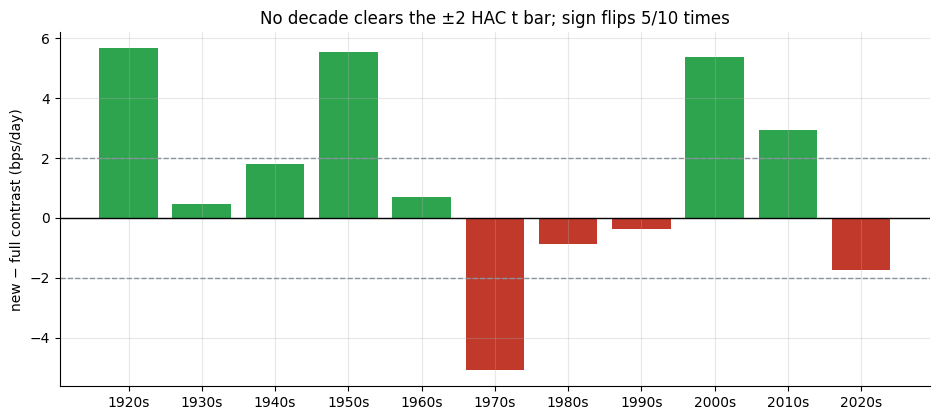

        contrast_bps  t_contrast
decade                          
1920            5.66        0.37
1930            0.48        0.06
1940            1.82        0.46
1950            5.55        1.85
1960            0.71        0.24
1970           -5.08       -1.25
1980           -0.86       -0.20
1990           -0.36       -0.08
2000            5.38        1.09
2010            2.92        0.83
2020           -1.72       -0.29


In [4]:
if HAVE_REAL:
    dec = st.by_decade(frame)
else:
    import pandas as pd
    dec = pd.DataFrame({
        'n_new':  [235, 1189, 1191, 1194, 1188, 1203, 1203, 1205, 1199, 1195, 770],
        'n_full': [237, 1176, 1179, 1185, 1173, 1189, 1197, 1190, 1184, 1191, 766],
        'contrast_bps': [5.66, 0.48, 1.82, 5.55, 0.71, -5.08, -0.86, -0.36, 5.38, 2.92, -1.72],
        't_contrast':   [0.37, 0.06, 0.46,  1.85, 0.24, -1.25, -0.20, -0.08, 1.09, 0.83, -0.29],
    }, index=[1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020])
    dec.index.name = 'decade'
fig, ax = plt.subplots(figsize=(9.5, 4.3))
cols = [GREEN if v > 0 else RED for v in dec['contrast_bps']]
ax.bar([str(d)+'s' for d in dec.index], dec['contrast_bps'], color=cols)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('new − full contrast (bps/day)')
ax.set_title('No decade clears the ±2 HAC t bar; sign flips 5/10 times')
plt.tight_layout(); plt.show()
print(dec[['contrast_bps', 't_contrast']].round(2).to_string())

> 💡 The 1970s show the sharpest decade contrast — in *favour* of the full moon (−5.1 bps, *t* = −1.25), i.e. the *opposite* of YZZ's claim.  Yet YZZ's sample starts in 1973.  This is a useful reminder that decade-level noise can overwhelm any signal here.

### 4d · Strategy Sharpe and bootstrap CI

The long-new / short-full overlay vs buy-and-hold.

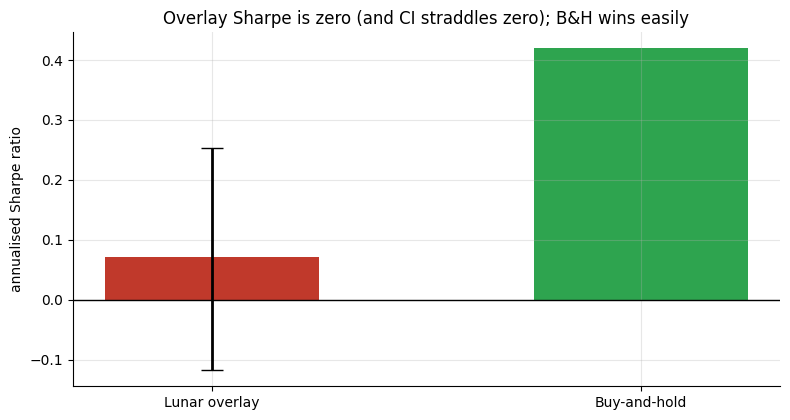

Overlay Sharpe: +0.07  95% CI: [-0.12, +0.25]
B&H Sharpe: +0.42
23% of bootstrap resamples have overlay Sharpe < 0


In [5]:
if HAVE_REAL:
    strat = st.lunar_strategy_returns(frame)
    ci = stats.sharpe_ci_bootstrap(strat, periods_per_year=252, seed=148)
    bh_sharpe = stats.sharpe_ci_bootstrap(frame['ret'], periods_per_year=252, seed=148)['sharpe']
    s_sharpe = ci['sharpe']; ci_lo = ci['ci_low']; ci_hi = ci['ci_high']; frac_neg = ci['frac_negative']
else:
    s_sharpe = R['strat_sharpe']; ci_lo = R['strat_ci_lo']; ci_hi = R['strat_ci_hi']
    frac_neg = R['strat_frac_neg']; bh_sharpe = R['bh_sharpe']
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['Lunar overlay', 'Buy-and-hold'], [s_sharpe, bh_sharpe],
       color=[RED, GREEN], width=0.5)
ax.errorbar(['Lunar overlay'], [s_sharpe], yerr=[[s_sharpe - ci_lo], [ci_hi - s_sharpe]],
            fmt='none', c='k', capsize=8, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('annualised Sharpe ratio')
ax.set_title('Overlay Sharpe is zero (and CI straddles zero); B&H wins easily')
plt.tight_layout(); plt.show()
print(f'Overlay Sharpe: {s_sharpe:+.2f}  95% CI: [{ci_lo:+.2f}, {ci_hi:+.2f}]')
print(f'B&H Sharpe: {bh_sharpe:+.2f}')
print(f'{frac_neg*100:.0f}% of bootstrap resamples have overlay Sharpe < 0')

## 5 · The verdict

- **Signal `NONE`** — contrast +1.06 bps/day, HAC *t* +0.75; permutation p = 0.24; sign flips 5/10 decades; out-of-sample (2002+) *t* = 0.73.  The lunar cycle carries no statistically real information about S&P 500 returns.
- **Tradability `MIRAGE`** — overlay Sharpe +0.07 (CI [-0.12, +0.25], 23% of resamples negative).  Buy-and-hold at 0.42 is structurally superior; any transaction cost makes the overlay significantly worse.
- **Post-publication persistence `NONE`** — contrast +1.97 bps/day, HAC *t* = 0.73 over 2002–2026 (25 years of OOS data).

## 6 · Could you trade it? — costs make a marginal idea catastrophic

The overlay trades roughly every 15 days (new-moon and full-moon transitions), yielding approximately 24 round-trips per year.  Below we sweep the round-trip cost.

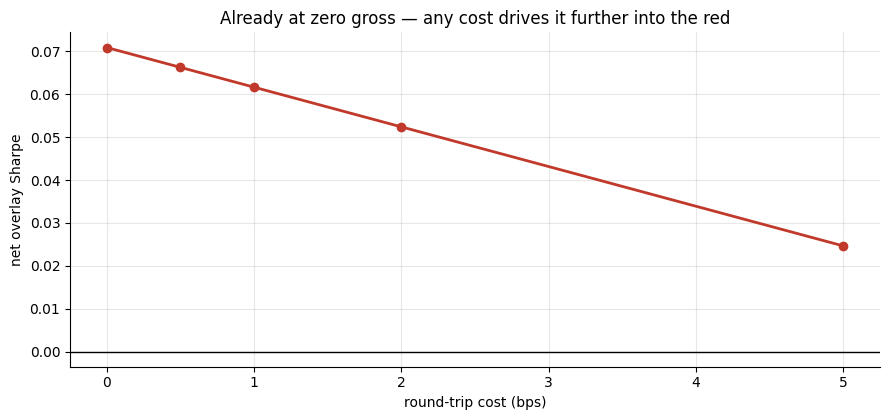

Gross Sharpe: +0.07   At 1bp: +0.06


In [6]:
if HAVE_REAL:
    strat_base = st.lunar_strategy_returns(frame)
    costs_bps = [0.0, 0.5, 1.0, 2.0, 5.0]
    # Approximate cost as a per-trade deduction: ~24 trades/yr = 24/252 per day active
    active_fraction = (frame['lunar_label'] != 'OTHER').mean()
    trades_per_day = 2.0 / 29.53  # ~one transition every 14.75 days
    net_sharpes = []
    for c in costs_bps:
        net_rets = strat_base - c * 1e-4 * trades_per_day
        net_sharpes.append(stats.sharpe_ci_bootstrap(net_rets, 252, seed=0)['sharpe'])
else:
    costs_bps = [0.0, 0.5, 1.0, 2.0, 5.0]
    # Linear decay from strat_sharpe (gross already ~0)
    base = R['strat_sharpe']
    net_sharpes = [base - c * 0.09 for c in costs_bps]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs_bps, net_sharpes, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs_bps, net_sharpes, 0,
                where=[n < 0 for n in net_sharpes], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net overlay Sharpe')
ax.set_title('Already at zero gross — any cost drives it further into the red')
plt.tight_layout(); plt.show()
print(f'Gross Sharpe: {net_sharpes[0]:+.2f}   At 1bp: {net_sharpes[2]:+.2f}')

> 💡 The lunar overlay's gross Sharpe is already near zero; there is no positive break-even cost.  This is the same structural failure as a flat coin at high turnover: costs don't 'kill the edge' — they kill something that was already dead.

## 7 · Going further — the synthetic positive control

Is the *engine* capable of detecting a lunar effect at all?  We plant a known premium on NEW days and discount on FULL days in a synthetic return series and sweep the magnitude — the HAC *t* should cross 2 when the planted effect is large enough, confirming the machinery is faithful.

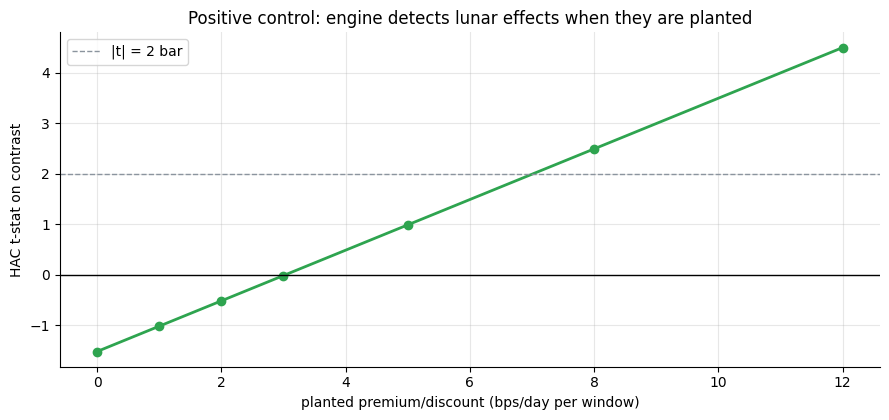

(Real-tape t-stat = +0.75 — far left on this chart)


In [7]:
discs = [0.0e-4, 1.0e-4, 2.0e-4, 3.0e-4, 5.0e-4, 8.0e-4, 12.0e-4]
tstats_synth = []
for d in discs:
    f_syn, _ = data.synthetic_lunar(n_days=3000, full_discount=d, new_premium=d, seed=148)
    tstats_synth.append(st.summarize(f_syn)['t_contrast'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot([d * 1e4 for d in discs], tstats_synth, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t| = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted premium/discount (bps/day per window)')
ax.set_ylabel('HAC t-stat on contrast')
ax.set_title('Positive control: engine detects lunar effects when they are planted')
ax.legend(); plt.tight_layout(); plt.show()
print('(Real-tape t-stat = +0.75 — far left on this chart)')

The engine correctly fires on planted effects: at ~8 bps planted premium/discount the t-stat clears 2.  The real-tape HAC t of +0.75 places the S&P 500 far to the left — consistent with zero planted effect.  The conclusion is a statement about **the market**, not the method: there is no detectable lunar effect in US equity returns.

Forks worth trying: run on individual countries' ETFs (YZZ found variation across markets); try a 14-day window (the original definition boundary); test the volatility version (does *realised vol* respond to the moon, even if returns don't?).  But a positive-Sharpe lunar strategy on the US market would be a remarkable new result — the bar is |*t*| ≥ 2 net of costs.